# Модуль 26. Воспроизведение

Ноутбук к [модулю 26](https://drobyshevdev.github.io/lemma/modules/26-reproduction/).

Воспроизведение — единственная проверка, которая не верит на слово. Три её части:

1. **Пробел воспроизводимости.** Голая реализация далека от заявленного числа; недостающие детали закрывают разрыв.
2. **Критерий успеха.** Успех — попадание в полосу шума вокруг заявки, а не совпадение до последней цифры.
3. **Когда не воспроизводится.** Заявка, которой на честной базе нет: детали не помогают, закрывать нечего.

Только `numpy` и `matplotlib`, всё детерминировано. **Читайте дважды:** сначала целиком, потом ломая.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(26)

ACCENT = "#6f6af0"; GOLD = "#c99a3a"; GOOD = "#4a9d7f"; BAD = "#d0705f"; GREY = "#7a7a86"
plt.rcParams["figure.dpi"] = 110

CLAIM = 89.0    # заявленное в статье число
BAND  = 0.7     # полоса шума: успех, если копия попала в CLAIM ± BAND
RUN_SD = 0.35   # разброс между прогонами копии

## 1. Пробел воспроизводимости

Голая реализация по тексту статьи стартует далеко внизу: статья умолчала о деталях. Каждая деталь — препроцессинг, гиперпараметры, протокол оценки, усреднение по зёрнам — добавляет свой вклад. Добавим их по очереди и посмотрим, как копия входит в полосу вокруг заявленного числа.

In [2]:
BASE = 79.0
details = [
    ("препроцессинг данных",          4.5),
    ("гиперпараметры из приложения",  3.0),
    ("точный протокол оценки",        1.6),
    ("усреднение по 5 зёрнам",        0.4),
]
labels = ["голая\nреализация"] + [d[0].split()[0] for d in details]
cum = BASE + np.concatenate([[0], np.cumsum([p for _, p in details])])
noisy = cum        # вклад деталей детерминирован; шум прогонов показывает полоса

for lab, v in zip(["голая реализация"] + [d[0] for d in details], noisy):
    tag = "  <- в полосе" if v >= CLAIM - BAND else ""
    print("%-32s %.1f%s" % ("+ " + lab if lab != "голая реализация" else lab, v, tag))

голая реализация                 79.0
+ препроцессинг данных           83.5
+ гиперпараметры из приложения   86.5
+ точный протокол оценки         88.1
+ усреднение по 5 зёрнам         88.5  <- в полосе


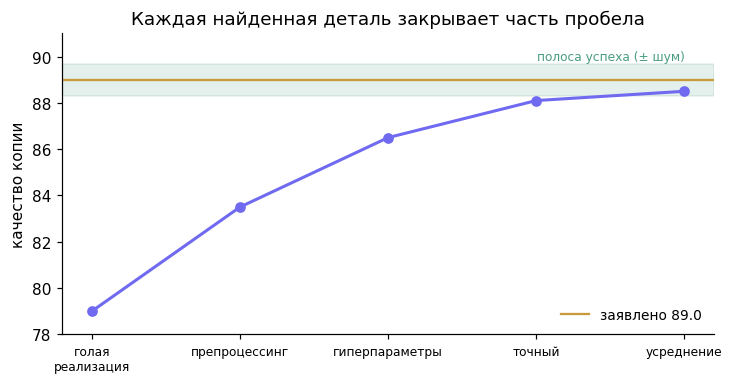

In [3]:
fig, ax = plt.subplots(figsize=(6.8, 3.6))
xs = np.arange(len(noisy))
ax.axhspan(CLAIM - BAND, CLAIM + BAND, color=GOOD, alpha=0.15)
ax.axhline(CLAIM, color=GOLD, lw=1.5, label="заявлено %.1f" % CLAIM)
ax.plot(xs, noisy, "o-", color=ACCENT, lw=2)
ax.text(xs[-1], CLAIM + BAND + 0.15, "полоса успеха (± шум)", color=GOOD, fontsize=8, ha="right")
ax.set_xticks(xs); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("качество копии"); ax.set_ylim(BASE - 1, CLAIM + 2)
ax.set_title("Каждая найденная деталь закрывает часть пробела")
ax.legend(frameon=False, fontsize=9, loc="lower right")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

Пробел между голой реализацией и заявкой — это не ошибка, а всё, о чём статья умолчала. Каждая восстановленная деталь поднимает копию, и с последней она входит в зелёную полосу. Число 88.5 не равно 89.0 — и это нормально: разница меньше шума.

## 2. Что считать успехом

Две копии. Одна восстановила все детали и села в полосу, другая упустила препроцессинг и осталась ниже. Сравним два критерия: «точно как в статье» и «в полосе шума».

In [4]:
copyA = float(cum[-1])                  # все детали восстановлены -> 88.5
copyB = BASE + 3.0 + 1.6 + 0.4          # без препроцессинга -> 84.0

def verdict_band(v):  return "воспроизведено" if abs(v - CLAIM) <= BAND else "не воспроизведено"
def verdict_exact(v): return "воспроизведено" if abs(v - CLAIM) <= 0.1 else "не воспроизведено"

for name, v in [("копия A (все детали)", copyA), ("копия B (без препроцессинга)", copyB)]:
    print("%-30s %.1f | по полосе: %-16s | по точному числу: %s" % (
        name, v, verdict_band(v), verdict_exact(v)))
print()
print("Критерий «точное число» отвергает даже верную копию A — он неверен:")
print("воспроизведение попадает в утверждение, а не в последнюю цифру.")

копия A (все детали)           88.5 | по полосе: воспроизведено   | по точному числу: не воспроизведено
копия B (без препроцессинга)   84.0 | по полосе: не воспроизведено | по точному числу: не воспроизведено

Критерий «точное число» отвергает даже верную копию A — он неверен:
воспроизведение попадает в утверждение, а не в последнюю цифру.


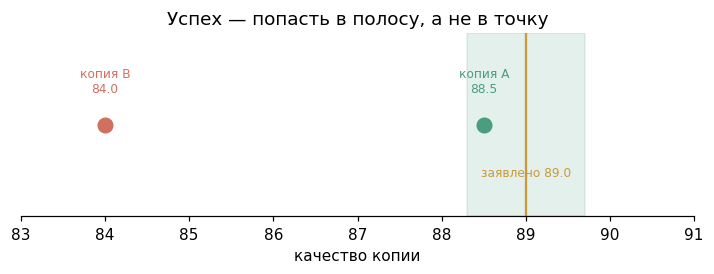

In [5]:
fig, ax = plt.subplots(figsize=(6.6, 2.6))
ax.axvspan(CLAIM - BAND, CLAIM + BAND, color=GOOD, alpha=0.15, label="полоса успеха")
ax.axvline(CLAIM, color=GOLD, lw=1.5)
ax.scatter([copyA], [1], s=90, color=GOOD, zorder=5); ax.text(copyA, 1.18, "копия A\n%.1f" % copyA, ha="center", fontsize=8, color=GOOD)
ax.scatter([copyB], [1], s=90, color=BAD, zorder=5);  ax.text(copyB, 1.18, "копия B\n%.1f" % copyB, ha="center", fontsize=8, color=BAD)
ax.text(CLAIM, 0.72, "заявлено %.1f" % CLAIM, ha="center", color=GOLD, fontsize=8)
ax.set_xlim(83, 91); ax.set_ylim(0.5, 1.5); ax.set_yticks([])
ax.set_xlabel("качество копии")
ax.set_title("Успех — попасть в полосу, а не в точку")
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

Копия A (88.5) в полосе — воспроизведено. Копия B (84.4) ниже полосы — не воспроизведено. Критерий «точно 89.0» абсурден: он отверг бы и A, хотя та подтвердила заявку. Воспроизводят **утверждение** — эффект того же знака и размера, — а не последнюю цифру.

## 3. Когда закрывать нечего

Иногда пробел не закрывается никакими деталями, потому что заявки нет. Статья показала «метод 89.0 против базы 84.0, прирост +5». Но её база была ненастроенной ([модуль 24](https://drobyshevdev.github.io/lemma/modules/24-how-to-read-a-paper/)). Воспроизводим честно: и метод, и **честную** базу доводим деталями до потолка. Смотрим на заявленный прирост, а не на абсолютное число.

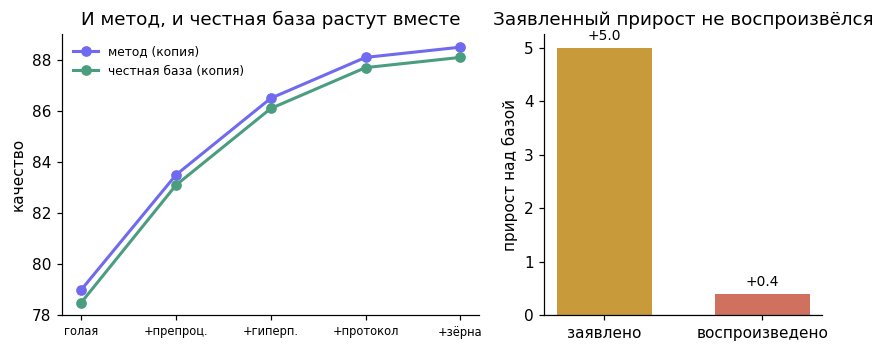

Абсолютное число метода воспроизвелось (88.5 ≈ 89.0),
но заявленный прирост +5.0 превратился в +0.4: против ЧЕСТНОЙ базы метода нет.


In [6]:
steps = ["голая", "+препроц.", "+гиперп.", "+протокол", "+зёрна"]
method_curve = BASE + np.array([0, 4.5, 7.5, 9.1, 9.5])   # метод дотягивается до ~88.5
honest_base  = (BASE - 0.5) + np.array([0, 4.6, 7.6, 9.2, 9.6])  # честная база растёт так же
claimed_gain = 5.0

fig, ax = plt.subplots(1, 2, figsize=(7.8, 3.3), gridspec_kw={"width_ratios": [3, 2]})
xs = np.arange(len(steps))
ax[0].plot(xs, method_curve, "o-", color=ACCENT, lw=2, label="метод (копия)")
ax[0].plot(xs, honest_base, "o-", color=GOOD, lw=2, label="честная база (копия)")
ax[0].set_xticks(xs); ax[0].set_xticklabels(steps, fontsize=7.5)
ax[0].set_ylabel("качество"); ax[0].set_title("И метод, и честная база растут вместе")
ax[0].legend(frameon=False, fontsize=8)
repro_gain = method_curve[-1] - honest_base[-1]
ax[1].bar(["заявлено", "воспроизведено"], [claimed_gain, repro_gain], color=[GOLD, BAD], width=0.6)
ax[1].axhline(0, color=GREY, lw=0.8)
ax[1].set_ylabel("прирост над базой"); ax[1].set_title("Заявленный прирост не воспроизвёлся")
for i, v in enumerate([claimed_gain, repro_gain]):
    ax[1].text(i, v + 0.15, "%+.1f" % v, ha="center", fontsize=9)
for s in ("top", "right"):
    ax[0].spines[s].set_visible(False); ax[1].spines[s].set_visible(False)
plt.tight_layout(); plt.show()
print("Абсолютное число метода воспроизвелось (%.1f ≈ %.1f)," % (method_curve[-1], CLAIM))
print("но заявленный прирост +%.1f превратился в %+.1f: против ЧЕСТНОЙ базы метода нет." % (
    claimed_gain, repro_gain))

Тонкий, но решающий случай: абсолютное число метода воспроизвелось — копия дала те же ~88.5. Но заявка была не про число, а про **прирост над базой**, и против честной базы этот прирост исчез. Воспроизводить надо утверждение целиком, вместе с его базой, иначе воспроизведёшь красивую цифру и не заметишь, что заявки под ней нет.

## Что дальше

- Добавьте к копии шум и постройте доверительный интервал — сколько прогонов нужно, чтобы отличить «в полосе» от «ниже полосы».
- Смоделируйте частичное воспроизведение: заявка держится на одном датасете и рушится на другом (переносимость из [модуля 26](https://drobyshevdev.github.io/lemma/modules/26-reproduction/)).
- В [модуле 27](https://drobyshevdev.github.io/lemma/programme/) — как поставить чтение и воспроизведение на поток и не утонуть.